# 4. Axis属性设置

- 在pyplot中的函数都是二次封装，重点封装了我们常用的两个对象Figure对象与Axes对象，并且提供对Figure与Axes对象的管理。尽管没有提供对Axis对象的管理（Axis由Axes负责管理），但是因为Axis太常用，在pyplot中还是提供了对Axis的二次封装函数。
- pyplot中的提供的对Figure对象与Axes对象的二次封装，都是对当前的Figure与Axes对象。

### 4.1  标题设置

- pyplot封装了两个函数来设置标题，一个是整个Figure的标题，一个是Axes的标题。
    - suptitle函数：为整个图形（Figure）添加总标题。
    - title函数：获取与设置Axes的标题。

- suptitle函数介绍
    - `matplotlib.pyplot.suptitle(t, **kwargs)`
        - 参数`t`：需要设置的标题，类型字符串。
        - 参数`**kwargs`：设置标题相关参数：
            - x, y: 设置标题在Figure的位置参数类型float。x默认值0.5，y默认值0.98. 单位是figure坐标系，在`0-1`之间。
            - horizontalalignment（简写ha）：标题在水平方向的位置，取值{'center', 'left', 'right'}, 默认是center
            - verticalalignment（简写va）：标题的在垂直方向的位置，取值{'top', 'center', 'bottom', 'baseline'}, 默认是top
            - fontsize（简写size）：标题的字体大小，参数类型是float。
            - fontweight（简写weight）：标签的权重（可以控制字体的粗细）
            - fontproperties：使用字典类型来设置字体属性（包含上面的fontsize与fontweight）
            - 还可以设置其他来自`matplotlib.text.Text`对象的属性。
        - 返回：Text类型的标题对象。 

- title函数说明：
    - `matplotlib.pyplot.title(label, fontdict=None, loc=None, pad=None, *, y=None, **kwargs)`
        - 参数`label`：坐标系Axes的标题，参数类型是str。
        - 参数`fontdict`(该参数不鼓励使用，鼓励使用的方式是单独参数设置)：设置字体相关属性，而且扩展了color等属性，参数类型是字典，字典支持的key有：
            - fontsize: 字体大小
            - fontweight: 字体权重
            - color: 字体颜色
            - verticalalignment:字体水平方向的对齐方式（水平方向位置）
            - horizontalalignment:字体垂直方向的对齐方式（垂直方向位置）
        - 参数`loc`：设置标题的位置，取值{'center', 'left', 'right'},默认值是'center'。该参数可以在环境变量`rcParams["axes.titlelocation"]`中设置。
        - 参数`pad`：设置标题离Axes顶部的距离，参数类型是float，单位是points，默认值是6.0。该参数可以在环境变量`rcParams["axes.titlepad"]`中设置。
        - 参数`y`：垂直方向标题的位置，1.0表示Axes的顶部，0表示Axes的底部，参数类型是float，该参数可以在环境变量`rcParams["axes.titley"]`中设置。
        - 参数`**kwargs`：来自Text对象的属性。

- 提示：
    - pyplot提供的函数涉及Figure与Axes对象的，都是当前Figure与Axes对象，使用这些函数的时候，注意切换Figure对象与Axes对象。

- 标题设置的例子

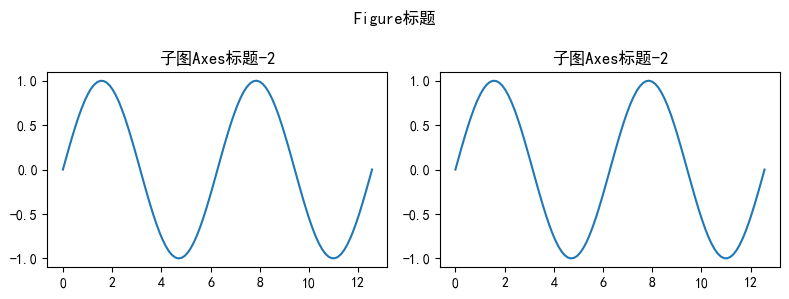

In [38]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 生成模拟数据（正弦曲线）
x = np.linspace(0, np.pi * 4, 100)
y = np.sin(x)


# 创建单个子图
plt.figure(figsize=(8, 3))

plt.subplot(121)
plt.plot(x, y)
plt.title('子图Axes标题-2')  # 为当前Axes子图添加标题

plt.subplot(122)
plt.plot(x, y)
plt.title('子图Axes标题-2')  # 为当前Axes子图添加标题

plt.suptitle("Figure标题")

plt.tight_layout()
plt.show()

- 标题相关参数设置的例子：

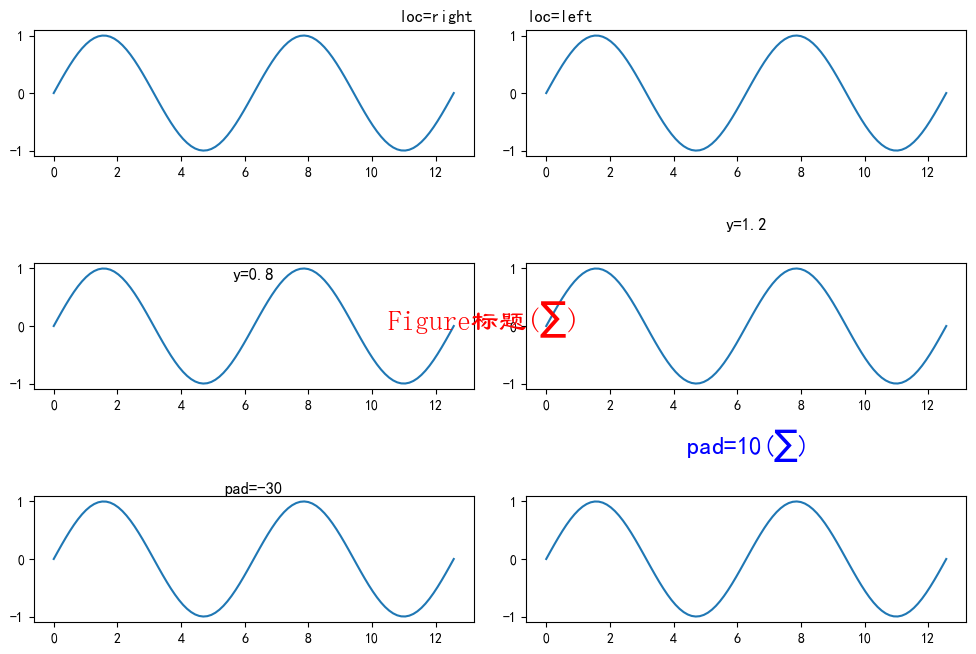

In [74]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 生成模拟数据（正弦曲线）
x = np.linspace(0, np.pi * 4, 100)
y = np.sin(x)


# 创建单个子图
plt.figure(figsize=(10, 7.2))
# ------------------------------loc
plt.subplot(321)
plt.plot(x, y)
plt.title(
    'loc=right',  # 为当前Axes子图添加标题
    loc="right",
)
plt.subplot(322)
plt.plot(x, y)
plt.title(
    'loc=left',  # 为当前Axes子图添加标题
    loc = "left",
)

# ------------------------------y
plt.subplot(323)
plt.plot(x, y)
plt.title(
    'y=0.8',  # 为当前Axes子图添加标题
    loc="center",
    y= 0.8
)
plt.subplot(324)
plt.plot(x, y)
plt.title(
    'y=1.2',  # 为当前Axes子图添加标题
    loc = "center",
    y= 1.2
)

# ------------------------------pad
plt.subplot(325)
plt.plot(x, y)
plt.title(
    'pad=-30',  # 为当前Axes子图添加标题
    loc="center",
    pad=0
)
plt.subplot(326)
plt.plot(x, y)
plt.title(
    r'pad=10($\sum$)',  # 为当前Axes子图添加标题
    loc = "center",
    pad=30,
    fontdict={    # 字体设置，不推荐使用
        "color": "red",
        "fontsize":18
    },
    color="blue"   # 来自Text的属性，比fontdict中设置的优先级更高。
)


plt.suptitle(
    "Figure标题($\\sum$)",
    x=0.5, y=0.5,    # 精确坐标定位，在0-1之间。
    horizontalalignment="center", # 该参数优先级低于x,y参数
    size=20,
    color="red",   # 来自Text的属性，**kwargs参数必须是关键字参数。
    fontproperties={   # 这个参数优先级低于size，fontsize与fontweight，weight。
        "size": 6,
        "family": "LiSu"
    }
)

plt.tight_layout()
plt.show()

- 代码说明：
    - title的pad参数是标题离Axes顶部的距离，从Axes开始计算，单位是Points，而且最小值是0，取负值，依然是取0值的效果。
    - suptitle的x,y参数可以精确定位，如果x，y参数设置，则horizontalalignment与verticalalignment无效。
    - 一般规则：当函数中一级参数(比如size)与参数的二级参数(比如fontproperties参数中fontsize)冲突，一般一级参数优先。
    - 提示在suptitle与title函数中，支持Latex语法。

### 4.2. 设置Axes的坐标轴显示范围与刻度

#### (1) 获取与设置Axes轴的显示范围-axis函数

- axis函数：获取与设置Axes轴的显示范围和一些显示属性。
    - 函数原型定义：`matplotlib.pyplot.axis(arg=None, /, *, emit=True, **kwargs)`
    - 函数的arg参数由如下使用四种方式：(注意下面都是核心参数，只能使用位置参数)
        - `xmin, xmax, ymin, ymax = axis()`：获取坐标轴显示范围。arg参数为None的情况
        - `xmin, xmax, ymin, ymax = axis([xmin, xmax, ymin, ymax])`  设置坐标轴显示范围，arg参数为数组的情况。
            - xmin, xmax, ymin, ymax参数类型是float。
        - `xmin, xmax, ymin, ymax = axis(option)`设置坐标轴属性，arg参数为bool与str的情况。
            - option参数类型bool或者str。取值如下：
                - "off"或者False：隐藏axis轴与装饰（包含标签labels, 轴spines, 刻度标记tick marks, 刻度标签tick labels, 网格线grid lines）
                - "on"或者True：显示axis轴与装饰。
                - "equal"：通过更改轴限制设置相等的缩放比例（即：使圆为圆形）。
                - "scaled"：通过更改绘图框的尺寸设置相等的缩放比例（即：使圆为圆形）。
                - "tight"：将显示范围设置得刚好显示所有数据。然后不再调用自动缩放 autoscale函数。
                - "auto"：自动缩放（用数据填充绘图框）
                - "image"：调增axis的显示范围为数据的显示范围。
                - "square"：等同于scaled，而且强制使得xmax-xmin==ymax-ymin
        - `xmin, xmax, ymin, ymax = axis(**kwargs)`
            - `**kwargs`来自Axes.set函数中的参数。
    - 返回值：`xmin, xmax, ymin, ymax`Axis坐标轴的显示范围。

- 使用axis设置轴范围的例子：
    - 等价与xlim与ylim

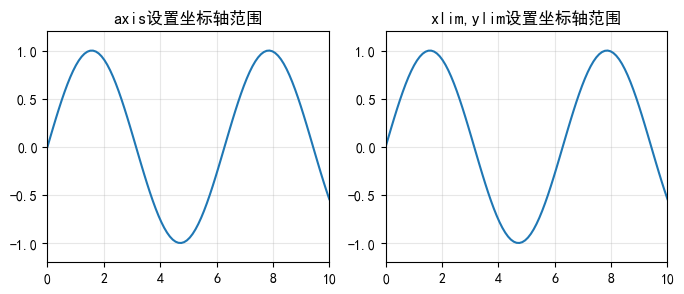

In [2]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(8,3))

plt.subplot(121)
plt.plot(x, y)
# 设置坐标轴范围 [xmin, xmax, ymin, ymax]
plt.axis([0,  10, -1.2,  1.2])
plt.title('axis设置坐标轴范围')
plt.grid(True, alpha=0.3)

plt.subplot(122)
plt.plot(x, y)
# 设置坐标轴范围 [xmin, xmax, ymin, ymax]
plt.xlim(0,10)
plt.ylim(-1.2, 1.2)
plt.title('xlim,ylim设置坐标轴范围')
plt.grid(True, alpha=0.3)


plt.show()

- 获取坐标轴显示范围

X轴范围: [-0.63, 13.19]
Y轴范围: [-1.10, 1.10]


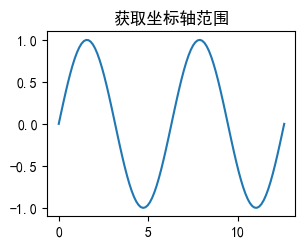

In [6]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

x = np.linspace(0, np.pi * 4, 100)
y = np.sin(x)

plt.figure(figsize=(3.2, 2.4))
plt.plot(x, y)
plt.title('获取坐标轴范围')
# 获取当前坐标轴范围
xmin, xmax, ymin, ymax = plt.axis()
print(f"X轴范围: [{xmin:.2f}, {xmax:.2f}]")
print(f"Y轴范围: [{ymin:.2f}, {ymax:.2f}]")

plt.show()

- 坐标轴显示范围控制模式例子：
    - `xmin, xmax, ymin, ymax = axis(option)`,option表示预定义的字符串或者bool值。

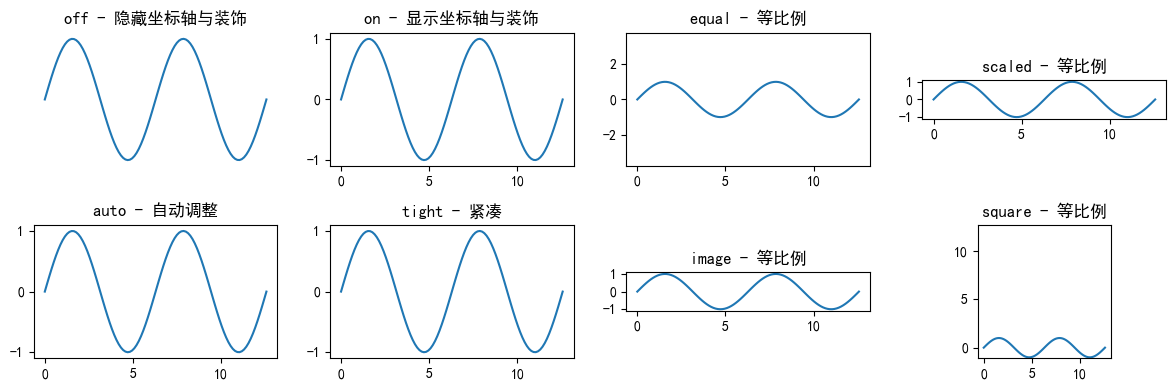

In [12]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

x = np.linspace(0, np.pi * 4, 100)
y = np.sin(x)

plt.figure(figsize=(12, 4))

plt.subplot(241)
plt.plot(x, y)
plt.axis('off')  # 自动调整范围（默认行为）
plt.title('off - 隐藏坐标轴与装饰')

plt.subplot(242)
plt.plot(x, y)
plt.axis('on')  # 紧密贴合数据
plt.title('on - 显示坐标轴与装饰')

plt.subplot(243)
plt.plot(x, y)
plt.axis('equal')  # 等比例缩放
plt.title('equal - 等比例')

plt.subplot(244)
plt.plot(x, y)
plt.axis('scaled')  # 自动调整范围（默认行为）
plt.title('scaled - 等比例')

plt.subplot(245)
plt.plot(x, y)
plt.axis('auto')  # 自动调整范围（默认行为）
plt.title('auto - 自动调整')

plt.subplot(246)
plt.plot(x, y)
plt.axis('tight')  # 自动调整范围（默认行为）
plt.title('tight - 紧凑')

plt.subplot(247)
plt.plot(x, y)
plt.axis('image')  # 自动调整范围（默认行为）
plt.title('image - 等比例')

plt.subplot(248)
plt.plot(x, y)
plt.axis('square')  # 自动调整范围（默认行为）
plt.title('square - 等比例')

plt.tight_layout()
plt.show()

- 代码说明：
    - 从代码运行的效果体验：
        - auto与tight效果一致，也auto应该是默认模式。
        - equal，scaled，square，image都是等比例模式，就是x，y的单位一致，不会因为Figure的比例不一致导致数值上的圆在显示出来是椭圆。但是等比例的处理方式不同：
            - equal：以figure的框大小（box）建立坐标轴（Box不变），但是更改显示范围（limit）保证xy的单位相等。
            - scaled：显示范围不变（limit），但是更改figure的box大小来保证xy的单位相等。
            - image：与scaled一样，但是Axes的刻度范围(Axis limits)与数据范围(Data limits)保持一致。实际上大部分情况，Axes的刻度范围与数据的显示范围是一样的。数据范围是使用plot这些函数的时候自动计算出来的范围。
            - square：与scaled一样，但是强制xy的显示范围一样（就是强制xmax-xmin == ymax-ymin）。
    - Axes limits(坐标轴刻度范围)与Data limits(数据显示范围)的说明：
        - Data Limits是传入数据并调用plot、scatter等绘图函数时，Matplotlib会分析这些数据，计算出能够完整容纳所有数据点的一个“最小矩形区域”。这个矩形区域的边界就是 Data Limits。
            - X 轴数据限制：`[min(x_data), max(x_data)]`
            - Y 轴数据限制：`[min(y_data), max(y_data)]`
            - Matplotlib 会在这个范围的基础上再稍微扩展一个边界（增加一个 margin），以确保数据点不会紧贴在坐标轴的边缘，让图看起来更舒适。
            - **注意**： Data Limits是只读的、由系统计算的，无法直接设置Data Limits。你只能通过改变数据来影响它。
        - Axis Limits 是最终呈现在图形上的、你实际看到的坐标轴范围。它是可以完全控制的部分。
            - 默认情况下，当你不做任何设置时，Axis Limits就等于Data Limits。
            - 你可以通过xlim和ylim方法来手动覆盖默认的Data Limits，从而自定义图形的显示区域。

- axis函数的emit参数：
    - 发送信号，提示matplotlib：Axis limits已经改变。

#### (2) 设置Axes的显示范围-xlim与ylim函数

- xlim, ylim函数：获取与设置Axes轴的显示范围。
    - `matplotlib.pyplot.xlim(*args, **kwargs)`
        - 获取当前x轴显示范围：`left, right = xlim()`
        - 设置当前x轴显示范围：`xlim((left, right))`或者`xlim(left, right)`
        - `**kwargs`参数，使用关键字参数，参数来自Axes.set_xlim函数的参数：
            - left，right：参数float类型，设置x坐标轴的显示范围最小值与最大值。
            - xmin，xmax：参数float类型。设置x坐标轴的显示范围最小值与最大值。
            - emit：参数bool类型，设置是否设置发送x坐标轴显示范围改变的消息。这个参数会触发事件`xlim_changed`。
            - auto：参数bool类型，默认False，设置为true,表示恢复使用数据自动计算x坐标轴显示范围。
        - 返回：left, right
    - `matplotlib.pyplot.ylim(*args, **kwargs)`
        - 获取当前y轴显示范围：`bottom, top = ylim()`
        - 设置当前y轴显示范围：`ylim((bottom, top))`或者`ylim(bottom, top)`
        - `**kwargs`参数，使用关键字参数，参数来自Axes.set_ylim函数的参数：
            - bottom，top：参数float类型，设置y坐标轴的显示范围最小值与最大值。
            - ymin，ymax：参数float类型。设置y坐标轴的显示范围最小值与最大值。与bottom与top参数一样的作用。
            - emit：参数bool类型，设置是否设置发送y坐标轴显示范围改变的消息。这个参数会触发事件`xlim_changed`。
            - auto：参数bool类型，默认False，设置为true,表示恢复使用数据自动计算y坐标轴显示范围。
        - 返回：bottom, top 

In [27]:
%matplotlib qt
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 创建数据
x = np.linspace(-10, 10, 200)
y = x**3 - 4*x

plt.figure(figsize=(10, 4), label="xlim与ylim函数的使用")   # label是GUI模式的窗体标题。

plt.subplot(121)
plt.plot(x, y)

# 显示静的状态
plt.xlim(-10, 10)
plt.ylim(-30, 30)
plt.title('')

# 显示axis limits的动态变化（局部放大）
plt.subplot(122)
# 先显示完整图形
plt.plot(x, y)

plt.xlim(-10, 10)
plt.ylim(-30, 30)
plt.title('原始图形')

plt.pause(3)  # 暂停几秒秒
# 通过axis limits变小，从而发达局部图形
plt.xlim(-2, 2)
plt.ylim(-10, 10)
plt.title('放大区域的图形')

plt.show()

- 代码说明：
    - 因为有动画或者交互，我们使用了GUI的运行模式。
    - `plt.pause(3)`代码表示运行进程的时候暂停3秒。

- 在xlim与ylim中使用auto参数

In [33]:
%matplotlib qt
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

x = np.linspace(0, 10, 100)
y = np.exp(x)

plt.plot(x, y)

# 先设置一个较小的范围
plt.xlim(0, 5)
plt.ylim(0, 100)
plt.title('精确值设置')

plt.pause(3)

# 然后恢复自动范围
plt.xlim(auto=True, emit=True)
plt.ylim(auto=True, emit=True)

x = np.linspace(0, np.pi * 2, 100)
y = np.sin(x)
plt.plot(x, y)     # plot等绘制函数触发auto的根据数据自动计算

plt.title('自动范围调整')
plt.show()

- 代码说明：
    - 当使用xlim与ylim的auto参数的时候，需要通过plot等绘制函数触发自动的Data limits的计算。

#### (3) 设置坐标轴刻度模式-xscale、yscale与autoscale函数

- xscale，yscale函数：设置坐标轴的刻度尺度，即坐标轴的数学变换方式。
    - `matplotlib.pyplot.xscale(value, **kwargs)`
    - `matplotlib.pyplot.yscale(value, **kwargs)`
        - value参数：参数类型是str或者ScaleBase对象。目前matplotlib的位置刻度有：
            - 'asinh'：反双曲正弦刻度
            - 'function'：通过数学函数来定义任意的刻度变换。
            - 'functionlog'：刻度在应用自定义函数变换之前，首先对数据进行对数变换。这种组合使得它特别适用于需要在对数空间中进行自定义操作的情况。
            - 'linear'： 线性刻度（默认）
            - 'log'：对数刻度
            - 'logit'：Logit刻度
            - 'symlog'：对称对数刻度
        - `**kwargs`参数：
            - 'asinh'：matplotlib.scale.AsinhScale
            - 'function'：matplotlib.scale.FuncScale
            - 'functionlog'：matplotlib.scale.FuncScaleLog
            - 'linear'：matplotlib.scale.LinearScale
            - 'log'：matplotlib.scale.LogScale
            - 'logit'：matplotlib.scale.LogitScale
            - 'symlog'：matplotlib.scale.SymmetricalLogScale

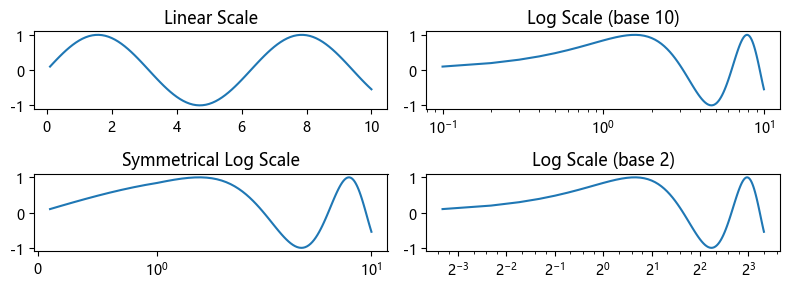

In [43]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 汉字字体支持
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 创建数据
x = np.linspace(0.1, 10, 100)
y = np.sin(x)

plt.figure(figsize=(8, 3))

# 线性比例尺（默认）
plt.subplot(221)
plt.plot(x, y)
plt.title('Linear Scale')

# 对数比例尺
plt.subplot(222)
plt.plot(x, y)
plt.xscale('log', base=10, subs=[2, 3, 4, 5, 6, 7, 8, 9])  # base与subs参数来自matplotlib.scale.LogScale
plt.title('Log Scale (base 10)')

# 对称对数比例尺
plt.subplot(223)
plt.plot(x, y)
plt.xscale('symlog', linthresh=1.0, linscale=0.5) # linthresh，linscale参数来自matplotlib.scale.SymmetricalLogScale
plt.title('Symmetrical Log Scale')

# 对数比例尺，底数为 2
plt.subplot(224)
plt.plot(x, y)
plt.xscale('log', base=2, subs=[1.5, 2.5, 3.5])
plt.title('Log Scale (base 2)')

plt.tight_layout()
plt.show()

- autoscale函数：自动调整坐标轴的显示范围以适应数据.
    - `matplotlib.pyplot.autoscale(enable=True, axis='both', tight=None)`
        - enable参数：开启自动坐标刻度计算（根据数据来计算），参数类型bool，True开启，False关闭。如果取值None表示保持原有状态。默认值是True。
        - axis参数：指定自动计算的坐标轴，取值{'both', 'x', 'y'}，默认值是"both"
        - tight参数：参数类型是bool，True表示不设置边界（即边界margin为0），并把该刻度传递给Axes.autoscale_view函数处理边界。

- autoscale在axis函数中设置auto=True的作用一样。这里不使用代码举例。

### 4.3. 坐标轴的修饰设置

#### (1) 变量与网格修饰-box与grid、rgrid是、thetagrid函数

- 边框修饰：
    - box函数：打开或者关闭Axes的矩形边框。
        - `matplotlib.pyplot.box(on=None)`
            - on参数：参数类型是bool类型。False表示关闭。True表示绘制边框线。默认的None表示开关操作（开启的就关闭，关闭的就开启）

- 网格修饰：
    - grid函数：在图表中显示或隐藏网格线，帮助更好地读取数据点的数值。
        - `matplotlib.pyplot.grid(visible=None, which='major', axis='both', **kwargs)`
            - visible参数：参数bool类型，用来设置是否显示网格线。
            - which参数：取值{'major', 'minor', 'both'}, 默认值是'major'。
            - axis参数：参数取值{'both', 'x', 'y'}，默认值是'both'。
            - `**kwargs`参数：来自Line2D对象的属性。可以控制网格线的样式。
    - rgrids函数：用于极坐标系的网格线控制，设置和自定义径向（半径方向）的网格线。
        - `matplotlib.pyplot.rgrids(radii=None, labels=None, angle=None, fmt=None, **kwargs)`
            - radii参数：指定极坐标网格线应该出现的位置。参数类型是float数组，代表绘制网格线所在的半径。参数为None，表示获取当前网格线Line2D对象数组与标签Text对象数组。（补充：极坐标的网格由围绕圆心的圆周线`[纬线，圆周]`与从圆心出发的半径线`[经线，径向]`。radii参数就是指定绘制网格线所在的半径，即纬线位置。）
            - labels参数：指定极坐标网格线的标签。参数类型是字符串数组。用来标注每个经线的标签。
            - angle参数：指定所有径向标签显示的角度，也是经线的角度。
            - fmt参数：用于格式化自动生成的数值标签的格式字符串。参数格式是%格式。
            - `**kwargs`参数：来自Text对象的属性。
        - 返回值： lines（Line2D对象数组）与labels（Text对象数组）
    - thetagrids函数：用于极坐标系的网格线控制，用于设置和自定义角度方向的网格线和标签。
        - `matplotlib.pyplot.thetagrids(angles=None, labels=None, fmt=None, **kwargs)`
            - angles参数：指定角度网格线的位置，参数类型是float数组。
            - labels参数：指定角度网格线的标签文本，参数类型是str数组。
            - fmt参数：格式化角度标签的格式字符串。
            - `**kwargs`参数：来自Text对象的属性。

- 标签修饰：
    - xlabel,ylabel函数：设置x,y坐标轴的标签。
        - `matplotlib.pyplot.xlabel(xlabel, fontdict=None, labelpad=None, *, loc=None, **kwargs)`
        - `matplotlib.pyplot.ylabel(ylabel, fontdict=None, labelpad=None, *, loc=None, **kwargs)`
            - xlabel参数与ylabel参数：x与y轴的标签，类型是str。
            - fontdict参数：设置x，y标签的字体，使用方式前面已经介绍过了。
            - labelpad参数: 设置标签举例坐标轴的间隔，参数类型是float，该参数默认值来自环境变量`rcParams["axes.labelpad"]`, 环境变量的默认值是4.0，单位是Points。
            - loc参数：设置标签在坐标轴的位置，ylabel取值{'bottom', 'center', 'top'}, xlabel取值{'left', 'center', 'right'}
                - xlabel可以用` rcParams["xaxis.labellocation"]`设置。默认是center
                - ylabel可以用` rcParams["yaxis.labellocation"]`设置。默认是center
            - `**kwargs`参数：来自Text对象的属性。

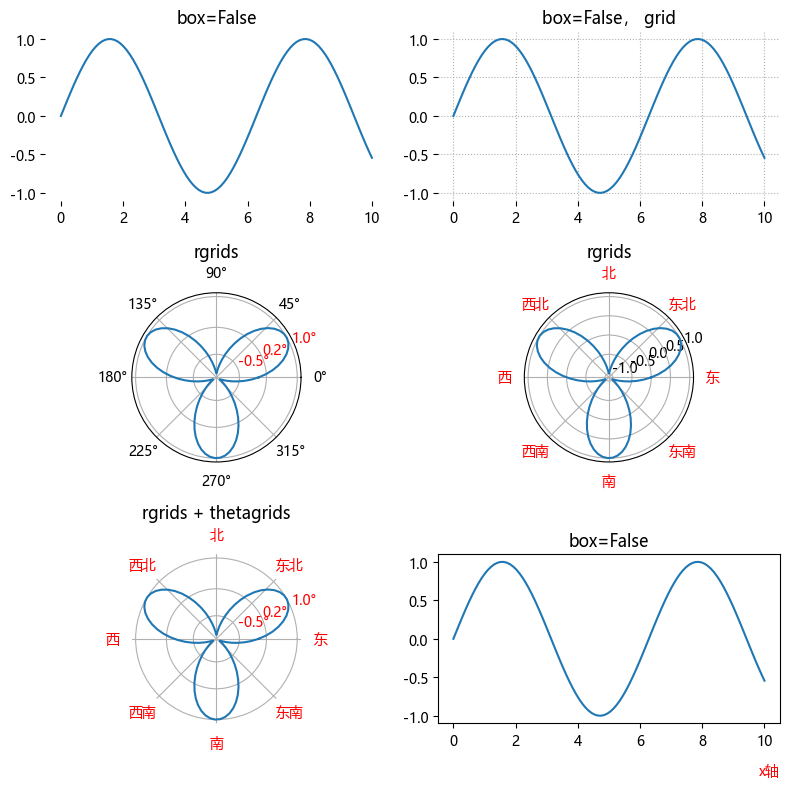

In [73]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 创建示例数据
x = np.linspace(0, 10, 100)
y = np.sin(x)

# 开始绘制
plt.figure(figsize=(8, 8))

# box------------------------------------
plt.subplot(321)
plt.plot(x, y)
plt.box(False)  # plt.box(on=False)
plt.title("box=False")

# grid------------------------------------
plt.subplot(322)  # 
plt.plot(x, y)
plt.box(on=False)
plt.grid(visible=True, which="both", axis="both", linestyle=":")
plt.title("box=False， grid")

# rgrids------------------------------------
theta = np.linspace(0, 2*np.pi, 100)
r = np.sin(3*theta)
plt.subplot(323, projection='polar')  # 极坐标
plt.plot(theta, r)

plt.rgrids(
    radii=[-0.5, 0.2, 1.0],
    labels=["-0.5°", "0.2°", "1.0°"],  # 与radii的数组长度一样。
    angle=22.5,
    color='red'
)

plt.title("rgrids")

# thetagrids------------------------------------
theta = np.linspace(0, 2*np.pi, 100)
r = np.sin(3*theta)
plt.subplot(324, projection='polar')  # 极坐标
plt.plot(theta, r)
# 设置角度网格线
plt.thetagrids(angles=[0, 45, 90, 135, 180, 225, 270, 315],
              labels=['东', '东北', '北', '西北', '西', '西南', '南', '东南'],
              fontsize=10, color='red')

plt.title("rgrids")

# rgrids + thetagrids------------------------------------
plt.subplot(325, projection='polar')  # 极坐标
theta = np.linspace(0, 2*np.pi, 100)
r = np.sin(3*theta)
plt.plot(theta, r)
plt.rgrids(
    radii=[-0.5, 0.2, 1.0],
    labels=["-0.5°", "0.2°", "1.0°"],  # 与radii的数组长度一样。
    angle=22.5,
    color='red'
)

# 设置角度网格线
plt.thetagrids(angles=[0, 45, 90, 135, 180, 225, 270, 315],
              labels=['东', '东北', '北', '西北', '西', '西南', '南', '东南'],
              fontsize=10, color='red')
plt.box(on=False)
plt.title("rgrids + thetagrids")
# xlabel, ylabel------------------------------------
plt.subplot(326)
plt.plot(x, y)
plt.title("xlabel")
plt.xlabel(
    "x轴", 
    labelpad=10, 
    loc="right",
    color="red"   # 来自Text的属性。
)

plt.tight_layout()
plt.show()


 - 代码说明：
     - 上面代码根据我们对函数的解释意义都比较明确，其中需要提到的，是我们可以同时使用rgrids函数与thetagrid函数控制经线与纬线的绘制。

#### (2) 精确控制坐标轴刻度的位置和标签-xticks与yticks函数

-  xticks与yticks函数：
    -  `matplotlib.pyplot.xticks(ticks=None, labels=None, *, minor=False, **kwargs)`
        - ticks参数：参数类型是float数组，用来设置刻度位置。参数如果设置为空，则不绘制刻度。
        - labels参数：参数类型是str数组，用来设置刻度的标签，这个参数只有ticks参数设置后有效。
        - minor参数：参数类型是bool类型，False表示绘制为主刻度，True表示绘制为次刻度。
        - `**kwargs`参数 ：来自Text对象的属性。
        - 返回值：
            - locs：返回每个刻度的位置。
            - labels：返回每个刻度对应的标签。
    - `matplotlib.pyplot.yticks(ticks=None, labels=None, *, minor=False, **kwargs)`
        - yticks的参数与xticks一样，只是yticks影响y轴，xticks影响x轴。

In [ ]:
- xticks与yticks的基本使用例子

6 [<matplotlib.axis.YTick object at 0x00000209A0255D10>, <matplotlib.axis.YTick object at 0x00000209A02579D0>, <matplotlib.axis.YTick object at 0x00000209A02C4190>, <matplotlib.axis.YTick object at 0x00000209A02C4910>, <matplotlib.axis.YTick object at 0x00000209A02C5090>, <matplotlib.axis.YTick object at 0x00000209A02C5810>]
[Text(0, -50, '0%'), Text(0, -30, '20%'), Text(0, -10, '40%'), Text(0, 10, '60%'), Text(0, 30, '80%'), Text(0, 50, '100%')]


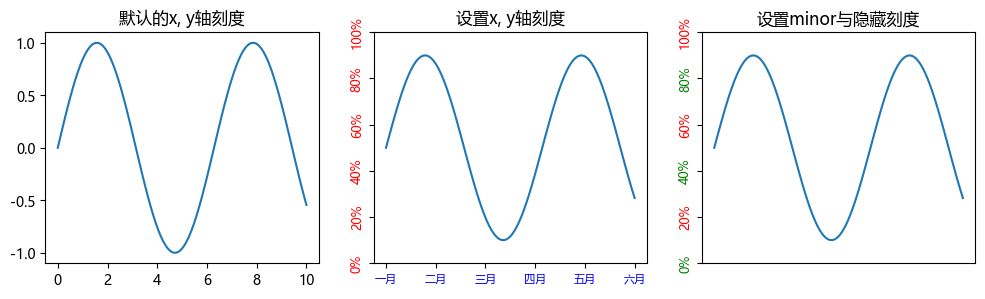

In [36]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 示例数据
x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(12, 3))

plt.subplot(131)
plt.plot(x, y)
plt.title('默认的x, y轴刻度')

plt.subplot(132)
plt.plot(x, y*40)
# 设置x轴刻度
plt.xticks([0, 2, 4, 6, 8, 10], 
           ['一月', '二月', '三月', '四月', '五月', '六月'],
           color='blue',
           fontsize=8)

# 设置x轴刻度
plt.yticks([-50, -30, -10, 10, 30, 50], 
           ['0%', '20%', '40%', '60%', '80%', '100%'],
           rotation=90,  # 来自Text对象 "horizontal", "vertical"
           va="center",  # m默认是top
           color='red',
           fontsize=9)

plt.title('设置x, y轴刻度')

plt.subplot(133)
plt.plot(x, y*40)
# 设置x轴刻度
plt.xticks([])   # 隐藏刻度

# 设置x轴刻度
locs, labels = plt.yticks([-50, -30, -10, 10, 30, 50], 
           ['0%', '20%', '40%', '60%', '80%', '100%'],
           rotation=90,  # 来自Text对象 "horizontal", "vertical"
           va="center",  # m默认是top
           color='red',
           fontsize=9)
print(len(locs), locs)
print(labels)
plt.title('设置minor与隐藏刻度')

# 精细控制标签
for idx, label in enumerate(labels):
    if idx % 2 == 0:
        label.set_color("green")
plt.show()

- 代码说明：
    - `plt.xticks([]) `，如果xticks与yticks参数为空，表示清楚刻度。
    - `for idx, label in enumerate(labels):`表示对返回的标签（Text对象），我们可以循环处理。
    - 在最后一个图表，使用了minor=True参数，所以可以看见次刻度被绘制，注意：需要注意次刻度的设置存在，才会绘制。

- 次刻度的使用例子：
    - minor参数的使用

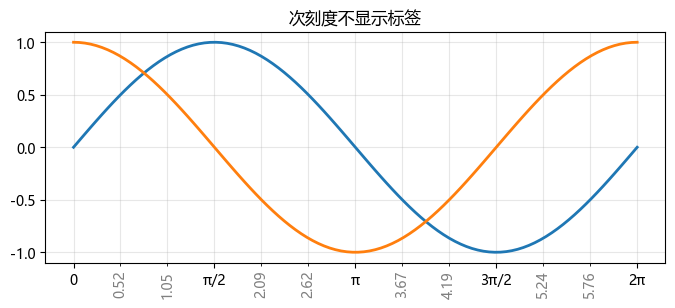

In [48]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

plt.figure(figsize=(8, 3))

x = np.linspace(0, 2*np.pi, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.plot(x, y1, label='sin(x)', linewidth=2)
plt.plot(x, y2, label='cos(x)', linewidth=2)

# 主刻度（显示标签）
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
           ['0', 'π/2', 'π', '3π/2', '2π'])

# 次刻度（不显示标签）
ticks = np.arange(0, 2*np.pi, np.pi/6)
labels = [F"{tick:3.2f}" for tick in ticks]

plt.xticks(minor=True, ticks=ticks, labels=labels, rotation=90, color="gray") # 绘制次刻度的标签
# plt.xticks(minor=True, ticks=ticks, labels=[""]*len(ticks)) # 不绘制次刻度标签

plt.title('次刻度不显示标签')
plt.grid(True, which='both', alpha=0.3)
plt.show()


- 代码说明：
    - `plt.xticks(minor=True, ticks=ticks, labels=labels, rotation=90, color="gray")`，在xticks与yticks函数中通过设置minor参数来选择设置主刻度，还是次刻度。

#### (3)设置坐标轴刻度定位器参数-locator_params函数

- 坐标轴刻度定位器是Matplotlib中一个控制刻度线位置的对象。它决定了在坐标轴的什么数值上显示刻度线和刻度标签。
    - 定位器负责决定在哪些位置画刻度线。
    - 格式化器负责决定在这些刻度线上显示什么文本标签。（下面介绍）
- locator_params函数主要作用：
    - 控制坐标轴刻度的密度和分布
    - 设置刻度显示的最多/最少数量
    - 调整刻度的紧凑程度
    - 指定应用设置的坐标轴

- locator_params函数的原型定义与参数说明：
    - `matplotlib.pyplot.locator_params(axis='both', tight=None, **kwargs)`
        - axis参数：
        - tight参数：
        - `**kwargs`参数：来自`matplotlib.axes.Axes.locator_params`函数的参数。
            - nbins参数：最大间隔数。参数类型是int类型或者'auto', 默认值是10，如果是auto表示自动计算。
            - steps参数：可接受的刻度倍数序列，从1开始，以10结束。参数类型是整数数组（注意：指定是的是刻度倍数）。
            - integer参数：参数是bool，True表示刻度只能取整数。默认是False。
            - symmetric参数：参数bool，True表示刻度是以0为中心对称，默认是False。
            - prune参数：如果坐标轴的下刻度、上刻度或两侧的刻度恰好落在轴的**边缘**上，则不会被绘制。
            - min_n_ticks参数：设置最小刻度数量。可以保证最小的刻度数量。即确保即使数据范围很小，也有足够数量的刻度显示。

- locator_params函数的axis，nbins，steps参数的使用例子。

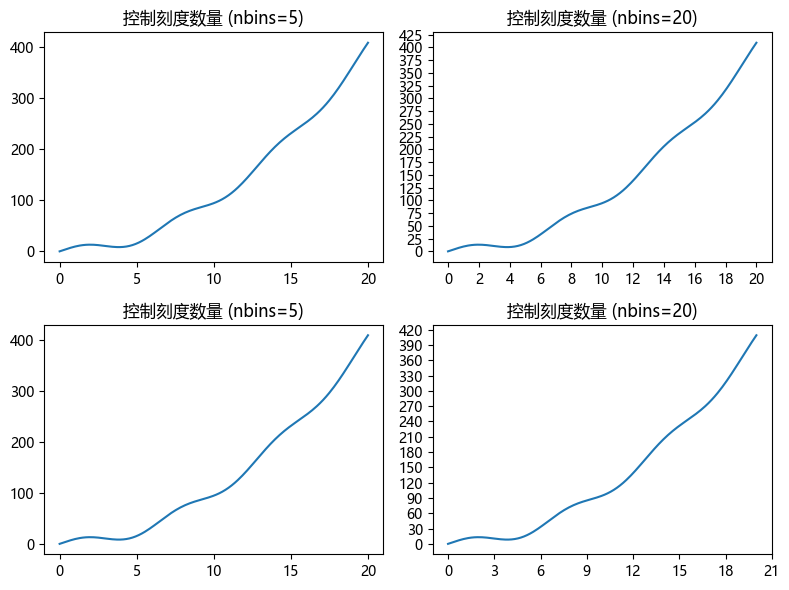

In [74]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 创建数据
x = np.linspace(0, 20, 200)
y = x**2 + 10*np.sin(x)

plt.figure(figsize=(8, 6))

# 1. 控制刻度数量-------------------nbins
plt.subplot(221)
plt.plot(x, y)
plt.locator_params(axis='both', nbins=5)
plt.title('控制刻度数量 (nbins=5)')

plt.subplot(222)
plt.plot(x, y)
plt.locator_params(axis='both', nbins=20)
plt.title('控制刻度数量 (nbins=20)')

# 2. 控制刻度可能得倍数-------------------steps
plt.subplot(223)
plt.plot(x, y)
plt.locator_params(axis='both', nbins=5, steps=[1, 3, 5, 7])
plt.title('nbins=5, steps=[1, 3, 5, 7])')

plt.subplot(224)
plt.plot(x, y)
plt.locator_params(axis='both', nbins=20, steps=[1, 3, 5, 7])
plt.title('nbins=20,steps=[1, 3, 5, 7]')

# 2. 控制刻度可能得倍数-------------------integer
plt.subplot(223)
plt.plot(x, y)
plt.locator_params(axis='both', nbins=5, steps=[1, 3, 5, 7])
plt.title('nbins=5, steps=[1, 3, 5, 7])')

plt.subplot(224)
plt.plot(x, y)
plt.locator_params(axis='both', nbins=20, steps=[1, 3, 5, 7])
plt.title('nbins=20,steps=[1, 3, 5, 7]')

plt.tight_layout()
plt.show()

- 代码说明：
    - nbins参数是指最大可能的刻度数，不是绝对数量。
    - steps参数是数组，数组的数据必须从小到大，表示是刻度可能的倍数。就是刻度必须是steps中指定的倍数。
    - nbins与steps都不是精确设置，matplotlib会根据数据自动计算调整。

- locator_params函数integer与symmetric参数的使用例子

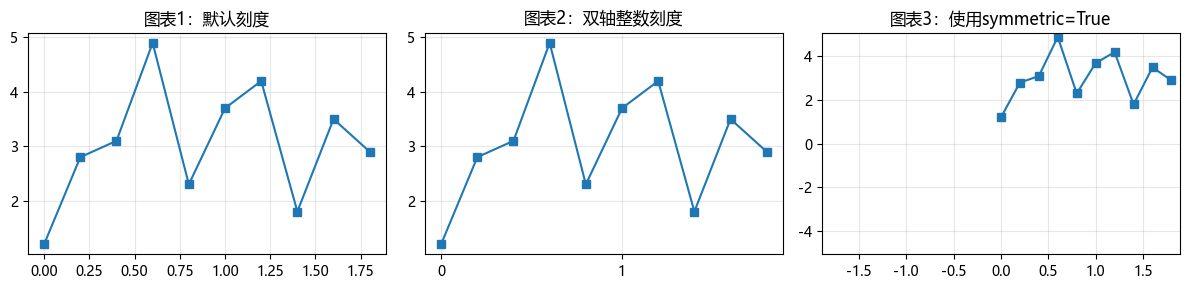

In [27]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 创建包含小数的数据
x = np.arange(0, 2, 0.2)
y = np.array([1.2, 2.8, 3.1, 4.9, 2.3, 3.7, 4.2, 1.8, 3.5, 2.9])

plt.figure(figsize=(12, 3))

# 1. 默认情况
plt.subplot(131)
plt.plot(x, y, 's-')
plt.title('图表1：默认刻度')
plt.grid(True, alpha=0.3)

# 2. 强制刻度是duicheng
plt.subplot(132)
plt.plot(x, y, 's-')
plt.locator_params(axis='both', integer=True)
plt.title('图表2：双轴整数刻度')
plt.grid(True, alpha=0.3)

# 3. 对称
plt.subplot(133)
plt.plot(x, y, 's-')
plt.locator_params(axis='both', symmetric=True)
plt.title('图表3：使用symmetric=True')
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

- 代码说明：
    - 为了明显看见效果，我们把x轴的数据调整的比较小。`x = np.arange(0, 2, 0.2)`, 然后在图表2中使用`integer=True`可以明显看见刻度是整数。
    - 在图表3中，是使用`symmetric=True`的结果，强制坐标轴刻度是以0为中心的对称。

- 参数min_n_ticks的使用例子。

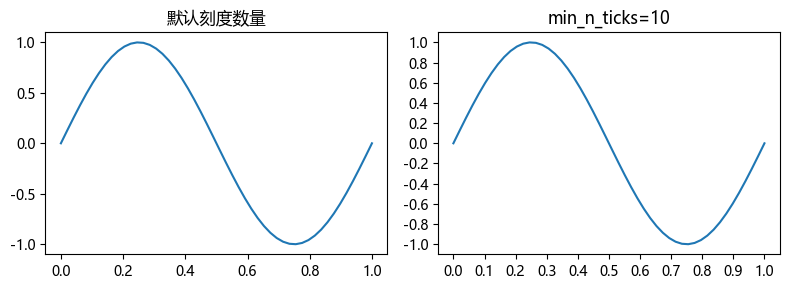

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 创建小范围数据
x = np.linspace(0, 1, 50)
y = np.sin(x * 2 * np.pi)

plt.figure(figsize=(8, 3))

# 默认情况
plt.subplot(121)
plt.plot(x, y)
plt.title('默认刻度数量')

# 设置最小刻度数量
plt.subplot(122)
plt.plot(x, y)
plt.locator_params(axis='both', min_n_ticks=10)
plt.title('min_n_ticks=10')

plt.tight_layout()
plt.show()

- prune参数对刻度裁剪的例子

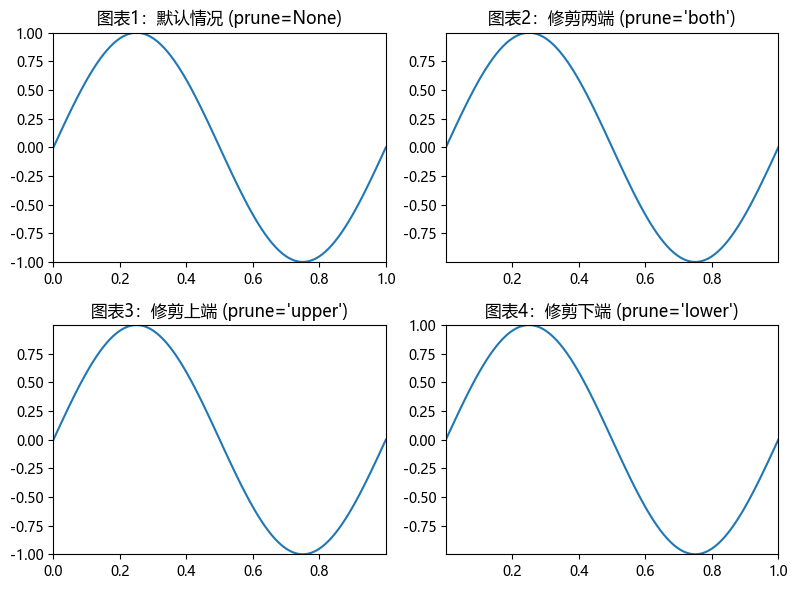

In [24]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。
# 创建示例数据
x = np.linspace(0, 1, 100)
y = np.sin(2 * np.pi * x)

# 创建对比图表
plt.figure(figsize=(8, 6))

# 1. 默认情况（不修剪）
plt.subplot(221)
plt.plot(x, y)
plt.title('图表1：默认情况 (prune=None)')
plt.xlim(0, 1)
plt.ylim(-1, 1)

# 2. 修剪两端
plt.subplot(222)
plt.plot(x, y)
plt.title("图表2：修剪两端 (prune='both')")
plt.xlim(0, 1)
plt.ylim(-1, 1)
plt.locator_params(axis='both', prune='both')

# 3. 修剪上端
plt.subplot(223)
plt.plot(x, y)
plt.title("图表3：修剪上端 (prune='upper')")
plt.xlim(0, 1)
plt.ylim(-1, 1)
plt.locator_params(axis='both', prune='upper')

# 4. 修剪下端
plt.subplot(224)
plt.plot(x, y)
plt.title("图表4：修剪下端 (prune='lower')")
plt.xlim(0, 1)
plt.ylim(-1, 1)
plt.locator_params(axis='both', prune='lower')

plt.tight_layout()
plt.show()

- 代码说明：
    - 为了明显看到效果，我们使用了代码`plt.xlim(0, 1)`与`plt.ylim(-1, 1)`把刻度精确的显示在两侧，可以看第一个图表1
    - 在图表2,3,4可以观察坐标轴两端的刻度是够被裁剪（是否显示）。

#### (4) 控制坐标轴刻度线和刻度标签的显示样式-tick_params函数

- tick_params函数原型定义与参数说明
    - `matplotlib.pyplot.tick_params(axis='both', **kwargs)`
        - axis参数：设置函数影响的坐标轴，取值{'x', 'y', 'both'}，默认是'both'。
        - `**kwargs`参数：（来自Axes.tick_params函数的参数）。
            - which参数：函数参数影响的刻度类型，取值{'major', 'minor', 'both'},默认'major'表示只影响主刻度。
            - reset参数：在更新刻度的时候，是否先重置到默认值。
            - direction参数：设置刻度的绘制方向：在坐标轴内还是外，或者两边都绘制，取值{'in', 'out', 'inout'}。
            - length参数：刻度的长度。
            - width参数：刻度的宽度。
            - color参数：刻度的颜色。
            - pad参数：刻度和标签的间距
            - labelsize参数: 标签的字体大小。
            - labelcolor参数：标签的字体颜色
            - labelfontfamily参数：标签的字体名。
            - colors参数：刻度与标签的颜色。
            - zorder参数：标签与刻度在Z方向的顺序（重叠顺序）。
            - bottom, top, left, right参数：刻度绘制的方位。
            - labelbottom, labeltop, labelleft, labelright参数：
            - labelrotation参数：标签的旋转角度。
            - grid_color参数：与刻度对应非网格线颜色。
            - grid_alpha参数：与刻度对应非网格线透明度。
            - grid_linewidth参数：与刻度对应非网格线宽度。
            - grid_linestyle参数：与刻度对应非网格线样式。
    - tick_params函数实际是`matplotlib.axes.Axes.tick_params`函数的二次封装，`**kwargs`参数都是来自这个函数。
    - **注意**：tick_params函数与locator_params函数的区别，tick_params函数主要是修饰刻度的外观与不布局。

- **控制影响的坐标轴与主次刻度**
    - axis参数：设置对参数设置影响那个坐标轴。
    - which参数：设置对参数设置影响主刻度还是次刻度。

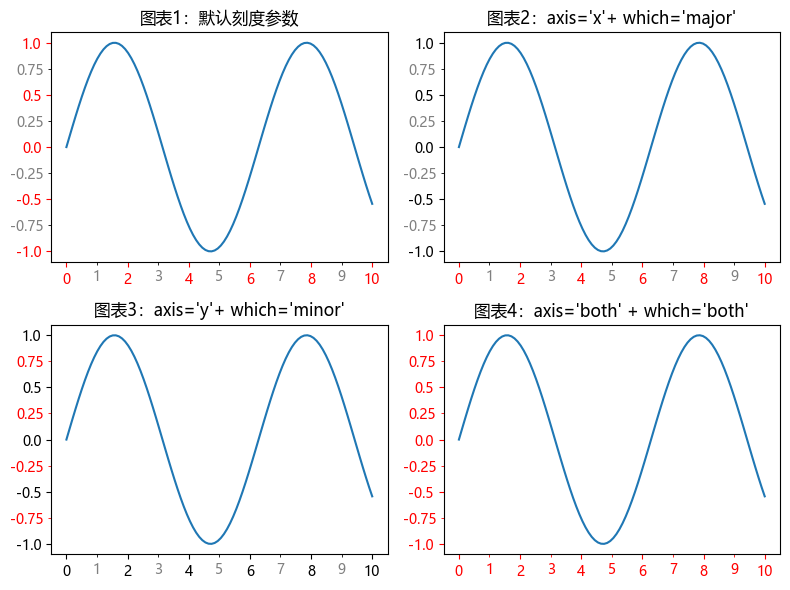

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(8, 6))

# 默认
plt.subplot(221)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")
# 默认刻度参数
plt.tick_params(colors='r')
plt.title("图表1：默认刻度参数")

# x 轴
plt.subplot(222)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")
# 只设置 x 轴的刻度
plt.tick_params(axis='x', which='major',  colors='r')
plt.title("图表2：axis='x'+ which='major'")

# y轴
plt.subplot(223)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")
# 只设置 x 轴的刻度
plt.tick_params(axis='y', which='minor',  colors='r')
plt.title("图表3：axis='y'+ which='minor'")

# both - xy轴
plt.subplot(224)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")
# 只设置 x 轴的刻度
plt.tick_params(axis='both', which='both',  colors='r')
plt.title("图表4：axis='both' + which='both'")

plt.tight_layout()
plt.show()

- 代码说明：
    - 为了体验效果，我们使用了color来设置刻度与刻度标签的颜色为红色。
    - 其中使用两行代码专门设置了次刻度：
        - `plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")`
        - `plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")`
    - 图表1使用使用默认ticks参数，我们可以看到axis参数默认是'both'.
    - 图表3只对y轴次刻度有效。图表4对xy轴的主次刻度都有效。

- **控制刻度线显示**
    - bottom，top，left，right参数：控制刻度绘制的方位，参数类型是bool。
    - dircection参数：控制刻度绘制的方向（在坐标轴内还是外）

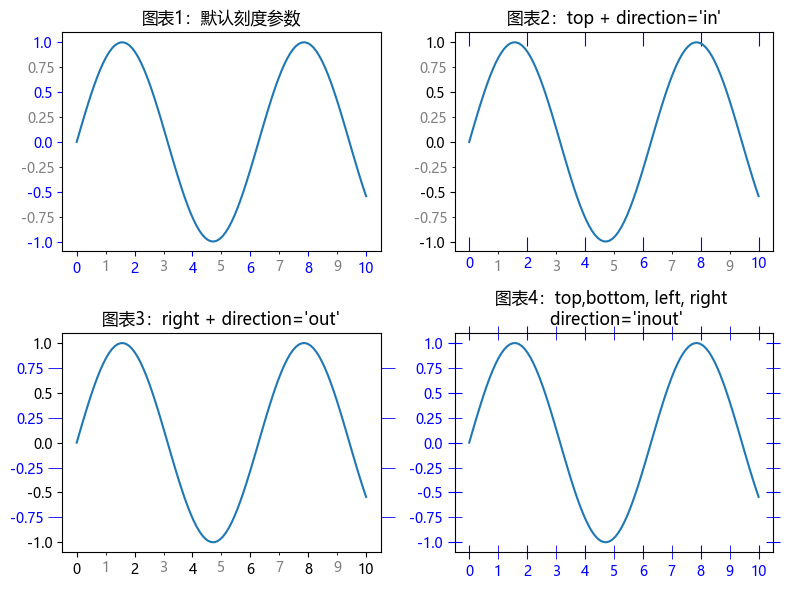

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(8, 6))

# 默认
plt.subplot(221)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")
# 默认刻度参数
plt.tick_params(colors='b')
plt.title("图表1：默认刻度参数")

# top + direction='in',
plt.subplot(222)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")

plt.tick_params(
    axis='x', which='major', 
    top=True,
    direction='in',
    length=10,
    colors='b')
plt.title("图表2：top + direction='in'")

# right + direction='out',
plt.subplot(223)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")
#  
plt.tick_params(
    axis='y', which='minor', 
    right=True,
    direction='out',
    length=10,
    colors='b')
plt.title("图表3：right + direction='out'")

# top,bottom, left, right + direction='inout',
plt.subplot(224)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")
# 只设置 x 轴的刻度
plt.tick_params(
    axis='both', which='both', 
    top=True,bottom=True, left=True, right=True,
    direction='inout',
    length=10,
    colors='b')
plt.title("图表4：top,bottom, left, right \n direction='inout'")

plt.tight_layout()
plt.show()

- 代码说明：
    - 为了突出体验效果，在参数中使用了length=10参数(单位是Points)，这样我们需要观察的刻度是长一点。
    - 在图表2,3,4中，我们看见刻度绘制在top与right方位的时候，没有绘制刻度的标签。
    - 图表2体验direction=in的效果，我们可以看到direction的默认方向是out。

- **控制刻度样式**
    - length参数：刻度的长度，在上面例子已经看到效果，单位是Points。
    - width参数：刻度的粗细，单位是Points。
    - color参数：设置刻度的颜色。

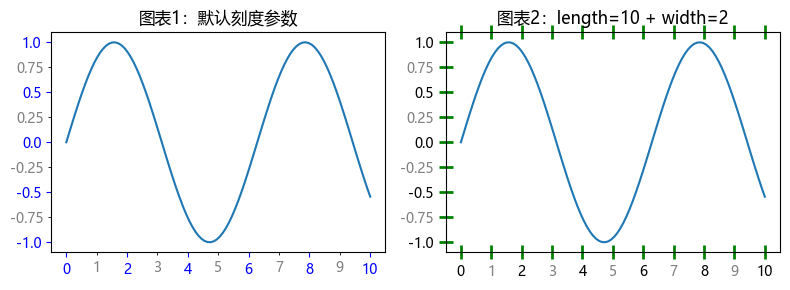

In [45]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(8, 3))

# 默认
plt.subplot(121)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")
# 默认刻度参数
plt.tick_params(colors='b')
plt.title("图表1：默认刻度参数")

# top + direction='in',
plt.subplot(122)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")

plt.tick_params(
    axis='both', which='both', 
    top=True,
    direction='inout',
    length=10,
    width=2,
    color='green')
plt.title("图表2：length=10 + width=2")


plt.tight_layout()
plt.show()

- 代码说明
    - 我们在上面例子的基础上，使用width，length与color参数。我们从实际效果看，color影响的是刻度，但是不影响刻度标签的颜色。
    - 注意length与width参数的单位是Points(磅)。

- **控制刻度标签显示方位**
    - labelbottom, labeltop, labelleft, labelright参数：控制标签显示的方位。参数类型是bool。
    - 提示：在前面的例子中，已经体验到当刻度在top与right的时候，默认是没有刻度标签的。

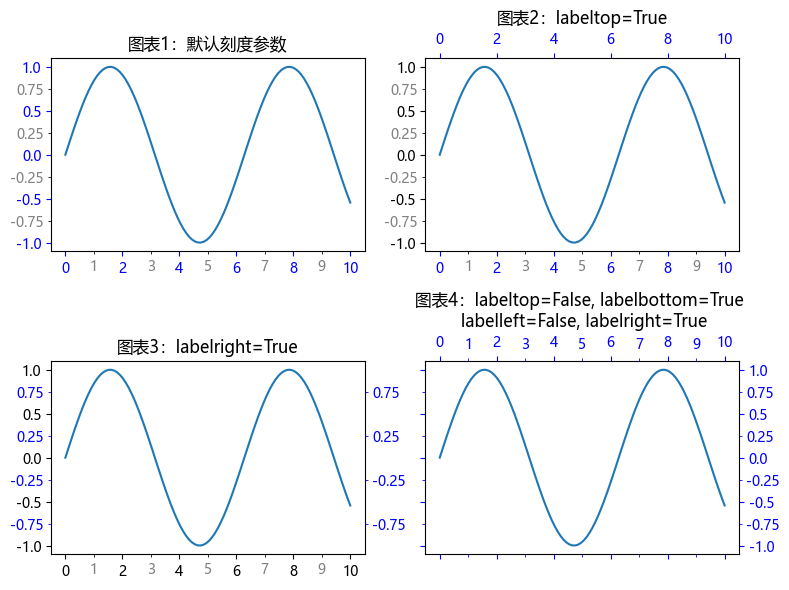

In [24]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(8, 6))

# 默认
plt.subplot(221)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")
# 默认刻度参数
plt.tick_params(colors='b')
plt.title("图表1：默认刻度参数")

# labeltop
plt.subplot(222)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")

plt.tick_params(
    axis='x', which='major', 
    top=True,
    labeltop=True,
    colors='b')
plt.title("图表2：labeltop=True")

# labelright=True
plt.subplot(223)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")
#  
plt.tick_params(
    axis='y', which='minor', 
    right=True,
    labelright=True,
    colors='b')
plt.title("图表3：labelright=True")

# labeltop, labelbottom, labelleft, labelright
plt.subplot(224)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")
# 只设置 x 轴的刻度
plt.tick_params(
    axis='both', which='both', 
    top=True, bottom=True, left=True, right=True,
    labeltop=True, labelbottom=False, labelleft=False, labelright=True,
    colors='b')
plt.title("图表4：labeltop=False, labelbottom=True \n labelleft=False, labelright=True")

plt.tight_layout()
plt.show()

- 代码说明
    - 通过labeltop,labelbottom,labelleft,labelright四个参数精确控制刻度标签是四个方位是否显示。

- **控制刻度标签样式**
    - labelfontfamily：标签的字体。
    - labelsize参数：标签的字体大小,单位是Points。
    - labelcolor参数：标签的字体颜色。
    - labelrotation参数：标签的旋转角度,参数类型float。
    - pad参数：标签与刻度之间的间距，单位是Points。

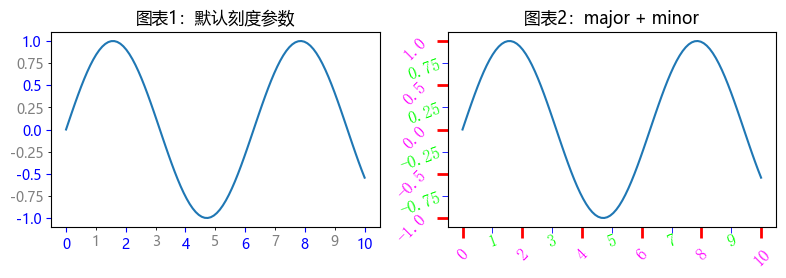

In [43]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(8, 3))

# 默认
plt.subplot(121)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")
# 默认刻度参数
plt.tick_params(colors='b')
plt.title("图表1：默认刻度参数")

# top + direction='in',
plt.subplot(122)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")

plt.tick_params(
    axis='both', which='major', 
    labelfontfamily='LiSu',
    labelsize=12,
    labelcolor='#FF00FFFF',
    labelrotation=45,
    width=2,
    length=8,
    color='red',
    pad=6,
    colors='green')

plt.tick_params(
    axis='both', which='minor', 
    labelfontfamily='LiSu',
    labelsize=12,
    labelcolor='#00FF00FF',
    labelrotation=20,
    length=4,
    color='blue',
    pad=0,
    colors='green')

plt.title("图表2：major + minor")


plt.tight_layout()
plt.show()

- 代码说明
    - 图表2，我们调用两次tick_params函数，用来对主次刻度进行分别设置，形成不同的样式绘制。
        - `plt.tick_params(axis='both', which='major', labelfontfamily='LiSu', labelsize=12, labelcolor='#FF00FFFF', labelrotation=45, width=2, length=8, color='red', pad=6, colors='green')` : 设置主刻度。
        - `plt.tick_params(axis='both', which='minor', labelfontfamily='LiSu', labelsize=12, labelcolor='#00FF00FF', labelrotation=20, length=4, color='blue', pad=0, colors='green')`：设置次刻度。

- **其他参数**
    - colors参数：刻度与刻度标签的颜色。注意：color是仅仅影响刻度颜色。（前面例子已经使用）
    - grid_color参数：网格线颜色。
    - grid_alpha参数：网格线透明度。
    - grid_linewidth参数：网格线宽。
    - grid_linestyle参数：网格线的样式。
    - zorder参数：设置标签与刻度的z-方向绘制顺序。（这个在绘制重叠的时候使用才有意义）

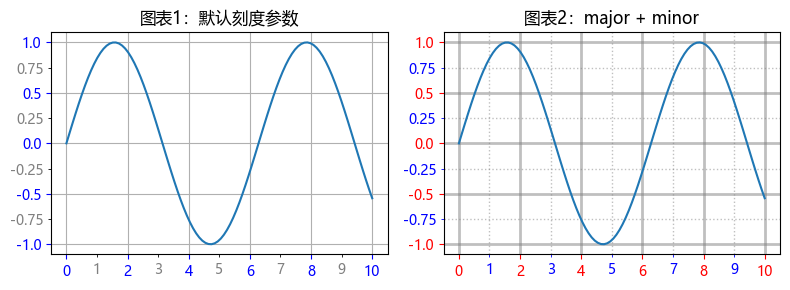

In [54]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(8, 3))

# 默认
plt.subplot(121)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")
# 默认刻度参数
plt.tick_params(colors='b')
plt.grid(True)
plt.title("图表1：默认刻度参数")

# top + direction='in',
plt.subplot(122)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")

plt.tick_params(
    axis='both', which='major',
    grid_color='gray',
    grid_alpha=0.5,
    grid_linewidth=2,
    grid_linestyle='-',
    colors="red"
)

plt.tick_params(
    axis='both', which='minor',
    grid_color='gray',
    grid_alpha=0.5,
    grid_linewidth=1,
    grid_linestyle=':',
    colors="blue"
)
plt.grid(True,which="both")
plt.title("图表2：主次网格线样式控制")


plt.tight_layout()
plt.show()

- 代码说明
    - 在函数tick_params中设置的网格线属性，不会自动显示，需要通过`plt.grid(True,which="both")`显示，而且主次刻度的显示也需要通过grid函数来设置是否显示。
    - 我们在代码中也分别设置主次刻度的网格线：
        - `plt.tick_params(axis='both', which='major', grid_color='gray', grid_alpha=0.5, grid_linewidth=2, grid_linestyle='-', colors="red")`
        - `plt.tick_params(axis='both', which='minor', grid_color='gray', grid_alpha=0.5, grid_linewidth=1, grid_linestyle=':', colors="blue")`

#### (5) 控制次刻度线的显示和隐藏-minorticks_off与minorticks_on函数

- 函数minorticks_on与minorticks_off函数用来控制次要刻度的显示与隐藏。
    - minorticks_on函数的原型定义与参数说明：
        - `matplotlib.pyplot.minorticks_on()`
            - 函数无参数
    - minorticks_off函数的原型定义与参数说明：
        - `matplotlib.pyplot.minorticks_off()`
            - 函数无参数

In [57]:
%matplotlib qt
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(8, 3))

# 默认
plt.subplot(121)
plt.plot(x, y)
plt.xticks(ticks=[1, 3, 5, 7, 9], labels=["1", "3", "5", "7", "9"], minor=True, color="gray")
plt.yticks(ticks=[-0.75, -0.25, 0.25, 0.75], labels=["-0.75", "-0.25", "0.25", "0.75"], minor=True, color="gray")
# 默认刻度参数
plt.tick_params(colors='b')
plt.grid(True, which="both")
plt.title("显示次要刻度")

plt.pause(3)

plt.title("隐藏次要刻度")
plt.minorticks_off()

plt.tight_layout()
plt.show()

- 代码说明：
    - 主次刻度的开启与关闭也会影响到主次网格线的显示与隐藏。
    - 我们使用GUI模式，通过交互式模式体验。`%matplotlib qt`, 通过暂停前后的差异来体验minorticks_off函数的作用与效果。

#### (6) 控制坐标轴刻度标签的数字格式化-ticklabel_format

- ticklabel_format函数：该函数实际是配置ScalarFormatter对象的构建参数，且只争对linear坐标系的刻度标签的格式化器。
    - `matplotlib.pyplot.ticklabel_format(*, axis='both', style=None, scilimits=None, useOffset=None, useLocale=None, useMathText=None)`
        - axis参数：设置影响的坐标轴，仅仅影响坐标轴的主刻度。取值{'x', 'y', 'both'}。默认值是'both'。
        - style参数：设置显示风格是否使用科学计数法，格式化器默认是科学计数法，参数取值{'sci', 'scientific', 'plain'}。其中'sci'等价于'scientific'。
        - scilimits参数：设置使用科学计数法的阈值，参数类型是整数对(m,n)，当数值超出$10^m$与$10^n$次方的范围就使用科学计数法。该值可以由环境变量`rcParams["axes.formatter.limits"]`配置默认值,默认值是`[-5, 6]`。
        - useOffset参数：设置是否显示偏移量，参数类型可以是：
            - bool：True表示显示，False表示不显示偏移量。
            - None：自动判断。
            - float：就是直接设置偏移量。
        - useLocale参数：设置是否使用本地化的数字格式（如千位分隔符），参数类型是bool，True表示使用本地格式化，False或者None表示不使用本地格式化。该参数的值可以由`rcParams["axes.formatter.use_locale"]`环境变量设置，缺省值是False。
        - useMathText参数：使用MathText渲染科学计数法，显示更美观的数学符号，参数类型是bool类型，可以由`rcParams["axes.formatter.use_mathtext"]`设置，默认值是False。

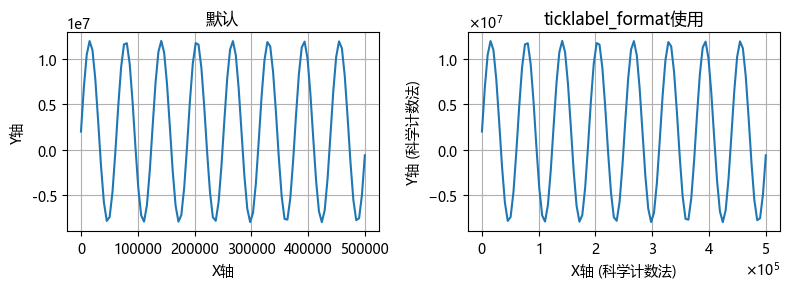

In [71]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 创建示例数据
x = np.linspace(0, 500000, 100)
y = 1e7 * np.sin(x/10000) + 2e6

plt.figure(figsize=(8, 3))
# --------------------默认
plt.subplot(121)
plt.plot(x, y)
plt.title('默认')
plt.xlabel('X轴')
plt.ylabel('Y轴')
plt.grid(True)

# -----------------------科学计数格式化
plt.subplot(122)
plt.plot(x, y)
# 综合配置
plt.ticklabel_format(
    axis='both',           # 应用于两个坐标轴
    style='sci',           # 科学计数法
    scilimits=(-3, 3),     # 在10^-3到10^3范围外使用科学计数法
    useOffset=True,       # 显示偏移量
    useMathText=True       # 使用美观的数学文本
)

plt.title('ticklabel_format使用')
plt.xlabel('X轴 (科学计数法)')
plt.ylabel('Y轴 (科学计数法)')
plt.grid(True)
plt.tight_layout()
plt.show()

- useOffset的参数体验例子：

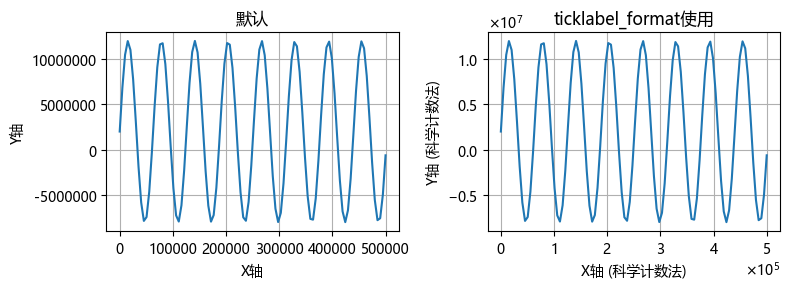

In [73]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 创建示例数据
x = np.linspace(0, 500000, 100)
y = 1e7 * np.sin(x/10000) + 2e6

plt.figure(figsize=(8, 3))
# --------------------默认
plt.subplot(121)
plt.plot(x, y)
plt.ticklabel_format(
    axis='both',
    style='plain',
    useOffset=True,       # 不显示偏移量
)
plt.title('默认')
plt.xlabel('X轴')
plt.ylabel('Y轴')
plt.grid(True)

# -----------------------科学计数格式化
plt.subplot(122)
plt.plot(x, y)
# 综合配置
plt.ticklabel_format(
    axis='both',           # 应用于两个坐标轴
    style='sci',           # 科学计数法
    scilimits=(-3, 3),     # 在10^-3到10^3范围外使用科学计数法
    useOffset=True,       # 显示偏移量
    useMathText=True       # 使用美观的数学文本
)

plt.title('ticklabel_format使用')
plt.xlabel('X轴 (科学计数法)')
plt.ylabel('Y轴 (科学计数法)')
plt.grid(True)
plt.tight_layout()
plt.show()

- useOffset参数与偏移表示法的使用例子：
    - 偏移表示法是为了刻度标签的简洁和易读，避免写出一长串的零。
    - 偏移表示法的表现方式是在坐标轴旁边显示一个偏移量，而刻度标签本身显示的是相对于该偏移量的差值。
    - 偏移表示法会在坐标轴旁边显示一个加/减的偏移量（如 +1e6），而每个刻度标签是原始值减去这个偏移量后的结果。比如：数值 1,000,100, 1,000,200, 1,000,300 可能会被显示为刻度标签 100, 200, 300，同时在坐标轴旁边标注一个 +1.000e6，表示实际数值是 标签值 + 1,000,000。

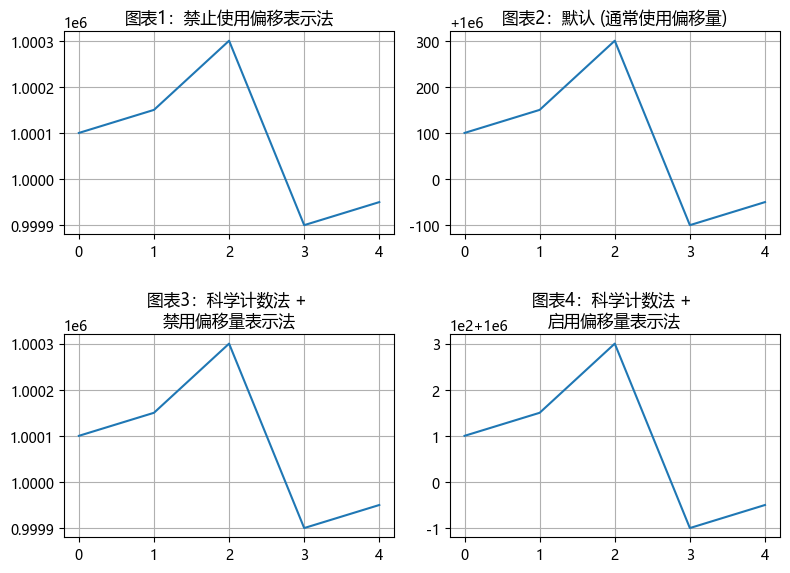

In [79]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

# 生成数据：在 1,000,000 附近有微小波动
x = np.arange(5)
y = np.array([1_000_100, 1_000_150, 1_000_300, 999_900, 999_950])

plt.figure(figsize=(8, 6))

# 默认情况，Matplotlib 会自动选择偏移量表示法
# 1. 禁用偏移量表示法
plt.subplot(221)
plt.plot(x, y)
plt.title('图表1：禁止使用偏移表示法')
plt.ticklabel_format(useOffset=False) # 禁止使用偏移表示法
plt.grid(True)
# 2. 启用偏移量表示法（也是模式）
plt.subplot(222)
plt.plot(x, y)
plt.ticklabel_format(useOffset=True) # 默认是偏移表示法
plt.title('图表2：默认 (通常使用偏移量)')
plt.grid(True)

# 科学计数法 + 禁用偏移量表示法
plt.subplot(223)
plt.plot(x, y)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useOffset=False) # 强制科学计数法
plt.title('图表3：科学计数法 + \n禁用偏移量表示法')
plt.grid(True)

# 科学计数法 + 启用偏移量表示法
plt.subplot(224)
plt.plot(x, y)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useOffset=True) # 强制科学计数法
plt.title('图表4：科学计数法 + \n启用偏移量表示法')
plt.grid(True)



plt.tight_layout()
plt.show()

- 代码说明：
    - 大家注意观察坐标系左上角的数值表示变化，把那个深入了解偏移表示法与科学表示法两种计数方法。

# 5. 环境配置

## 5.1. 环境设置与获取

- matplotlib中对大量在可视化中使用的数据，用环境变量的方式存储，这些变量的管理有RcParams类来负责。RcParams类在matplotlib中提供一个实例对象rcParams来实现这些变量的管理。
- pyplot提供rc函数来实现对matplotlib的rcParams对象的操作进行二次封装。使用rc函数与使用rcParams对象的效果是一致的。

### (1) 环境变量设置与获取-RcParams类与rcParams对象

- RcParams类的构造器定义：
    - `class matplotlib.RcParams(*args, **kwargs)`
        - 构造器参数用于配置参数的类似字典的键值存储，以及参数的验证函数。
            - 比如验证值是否float类型的函数：`matplotlib.rcsetup.validate_float(s)`等。
            - 可用的验证函数很多，这里我们提供官方的文档地址：`https://matplotlib.org/stable/api/rcsetup_api.html#module-matplotlib.rcsetup`
        - 构造器可以配置的key也是预定义的：
            - 比如： `axes.facecolor`
            - 可用的配置参数的key很多，我们这里提供官方文档地址：`https://matplotlib.org/stable/api/matplotlib_configuration_api.html#matplotlib.rcParams`

- 我们在前面已经使用RcParams的实例对象进行了字体的设置，并解决了中文以及一些特殊符号的乱码问题。
    - `plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]`
    - `plt.rcParams['axes.unicode_minus'] = False`

- 使用RcParams设置环境变量的例子：
    - 我们使用lines相关参数举例
        - lines.color
        - lines.linestyle
    - 因为RcParams类已经在matplotlib中已经被实例化为rcParams对象，我们直接使用即可。
        - `matplotlib.rcParams`：也可以使用matplotlib模块访问。访问方式使用字典方式访问。因为该类继承了dict类`class RcParams(MutableMapping, dict):`。

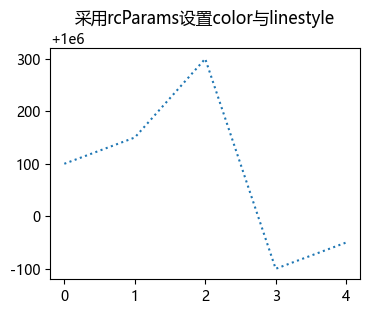

In [93]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。
import matplotlib as mt
mt.rcParams["lines.color"] = "#FF0000"
mt.rcParams["lines.linestyle"] = ":"

# 生成数据：在 1,000,000 附近有微小波动
x = np.arange(5)
y = np.array([1_000_100, 1_000_150, 1_000_300, 999_900, 999_950])

plt.figure(figsize=(4, 3))


plt.plot(x, y)

plt.title('采用rcParams设置color与linestyle')
plt.show()

- 代码说明：
    - 上面线条样式起作用了，但是线条颜色没有影响，因为在绘制线条的时候，颜色循环（color cycle）的优先级更高。可以修改颜色循环方案。
    - rcParams对象可以通过`matplotlib`与`matplotlib.pyplot`两个模块访问。

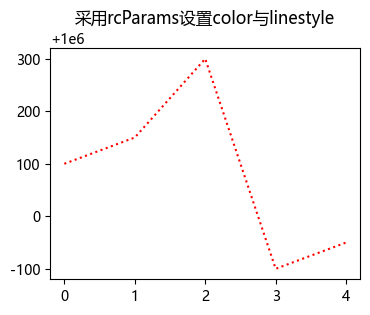

In [96]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。
import matplotlib as mt
mt.rcParams["lines.color"] = "#FF0000"
mt.rcParams["lines.linestyle"] = ":"
mt.rcParams["axes.prop_cycle"] = plt.cycler(color=['red'])
# 生成数据：在 1,000,000 附近有微小波动
x = np.arange(5)
y = np.array([1_000_100, 1_000_150, 1_000_300, 999_900, 999_950])

plt.figure(figsize=(4, 3))


plt.plot(x, y)

plt.title('axes.prop_cycle与lines.color的冲突')
plt.show()

- 代码说明：
    - 在代码中，我们使用了cycler函数来生成颜色循环，这个函数在颜色主题中，我们会详细介绍。

- 设置参数的另外一种使用方式
    - 使用dict字典的update函数。

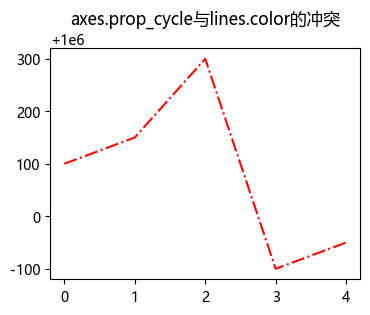

In [99]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

lines_params = {
    'lines.linestyle': "-.",
    'lines.color': "#FF00FF",
    'axes.prop_cycle': plt.cycler(color=['red'])
}
plt.rcParams.update(lines_params)
# 生成数据：在 1,000,000 附近有微小波动
x = np.arange(5)
y = np.array([1_000_100, 1_000_150, 1_000_300, 999_900, 999_950])

plt.figure(figsize=(4, 3))


plt.plot(x, y)

plt.title('axes.prop_cycle与lines.color的冲突')
plt.show()

- 查看环境参数变量：
    - 因为环境参数变量的管理对象rcParams本身就是字典

In [102]:
import matplotlib.pyplot as plt
import numpy as np

for key, val in plt.rcParams.items():
    print(key,":\t", val)
    break  # 可以注释掉，输出所有环境变量与默认值。

_internal.classic_mode :	 False


- 查询环境变量
    - 通过 rcParams的成员函数`find_all(pattern)`来进行模式匹配查询。

In [105]:
import matplotlib.pyplot as plt
import numpy as np

query = plt.rcParams.find_all("^lines.*")
print(query)

lines.antialiased: True
lines.color: #FF00FF
lines.dash_capstyle: CapStyle.butt
lines.dash_joinstyle: JoinStyle.round
lines.dashdot_pattern: [6.4, 1.6, 1.0, 1.6]
lines.dashed_pattern: [3.7, 1.6]
lines.dotted_pattern: [1.0, 1.65]
lines.linestyle: -.
lines.linewidth: 1.5
lines.marker: None
lines.markeredgecolor: auto
lines.markeredgewidth: 1.0
lines.markerfacecolor: auto
lines.markersize: 6.0
lines.scale_dashes: True
lines.solid_capstyle: CapStyle.projecting
lines.solid_joinstyle: JoinStyle.round


- 代码说明：
    - 在代码中我们使用了正则表达式`^lines.*`:以字符串`lines.`开头的所有环境变量。

- 环境参数的验证器由rcsetup._validators存储与管理
    - 可以通过rcsetup._validators来更新与获取验证器。
    - 学习者需要建议了解**正则表达式语法**。

- 我们体验matplotlib提供的变量参数值的类型验证器。

In [109]:
import matplotlib.pyplot as plt
import numpy as np

# 获取特定参数的验证函数
validator = plt.rcsetup._validators['lines.linewidth']
print(validator)
# 验证值
try:
    validator(2.5)  # 返回验证后的值
    validator("2.5")  # 返回验证后的值
    validator("a2.5")  # 返回验证后的值
    print("值有效")
except ValueError as e:
    print(f"验证失败: {e}")

<function _make_type_validator.<locals>.validate_float at 0x00000231DC880900>
验证失败: Could not convert 'a2.5' to float


- 列出matplotlib注册的验证器

In [111]:
import matplotlib as mpl
import numpy as np

# 获取特定参数的验证函数
for name, validator in mpl.rcsetup._validators.items():
    print(name, ":\t", validator)
    break  # 可以

backend :	 <function validate_backend at 0x00000231DC880D60>


### (2) 环境变量的设置与获取-rc函数

- rc函数是对rcParams对象操作的二次封装，使用简洁，函数原型定义与参数说明：
    - `matplotlib.pyplot.rc(group, **kwargs)`
        - group参数：指定变量的分组，前面每个变量名的前缀就是分组名，比如'lines'就是组名。
        - `**kwargs`参数：就是前面去掉前缀的变量名。
        - 函数没有返回值。

- 设置变量参数的值

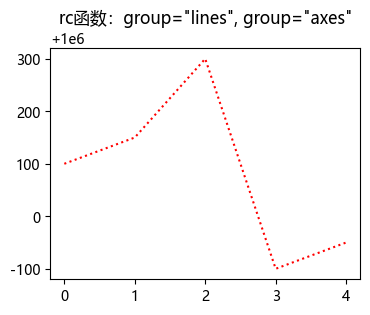

In [114]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc(group="lines", linestyle=":", color="green")
mpl.rc(group="axes", prop_cycle=plt.cycler(color=['red']))

x = np.arange(5)
y = np.array([1_000_100, 1_000_150, 1_000_300, 999_900, 999_950])

plt.figure(figsize=(4, 3))
plt.plot(x, y)

plt.title('rc函数：group="lines", group="axes"')
plt.show()

- 代码说明：
    - 比起对象的字典访问，rc函数更符合直观、更加简洁。但是rc函数只能设置值，不能查询变量值。

- 环境变量的存储
    - 上面的环境变量是永久存储的（就是存储在硬盘上的），存储的文件名：`matplotlibrc`,matplotlib通常从四个位置搜索并加载该文件。
        - 当前工作路径下找matplotlibrc文件加载。这个对特定项目非常有效。
        - `$MATPLOTLIBRC$`，从系统环境变量中获取，如果是文件就直接加载，如果是目录就加载`$MATPLOTLIBRC$/matplotlibrc`。
        - 用户主目录下`.config/matplotlib/matplotlibrc`文件（这是Linux）。
            - window等其他系统：`.matplotlib/matplotlibrc`
            - 注意：点开头的文件是隐藏文件。
        - 在安装路径下查找`INSTALL/matplotlib/mpl-data/matplotlibrc`,在linux下的安装路径一般看起来像这样`/usr/lib/python3.10/site-packages`。
            - window下看起来像这样`C:\Python310\Lib\site-packages`，我的电脑是`C:\Program Files\Python313\Lib\site-packages\matplotlib\mpl-data\matplotlibrc`
    - 这个文件的路径因系统不同而不同，但是记住文件名可以通过搜索找到位置路径。

- 环境变量存储文件的内容格式截图如下：

>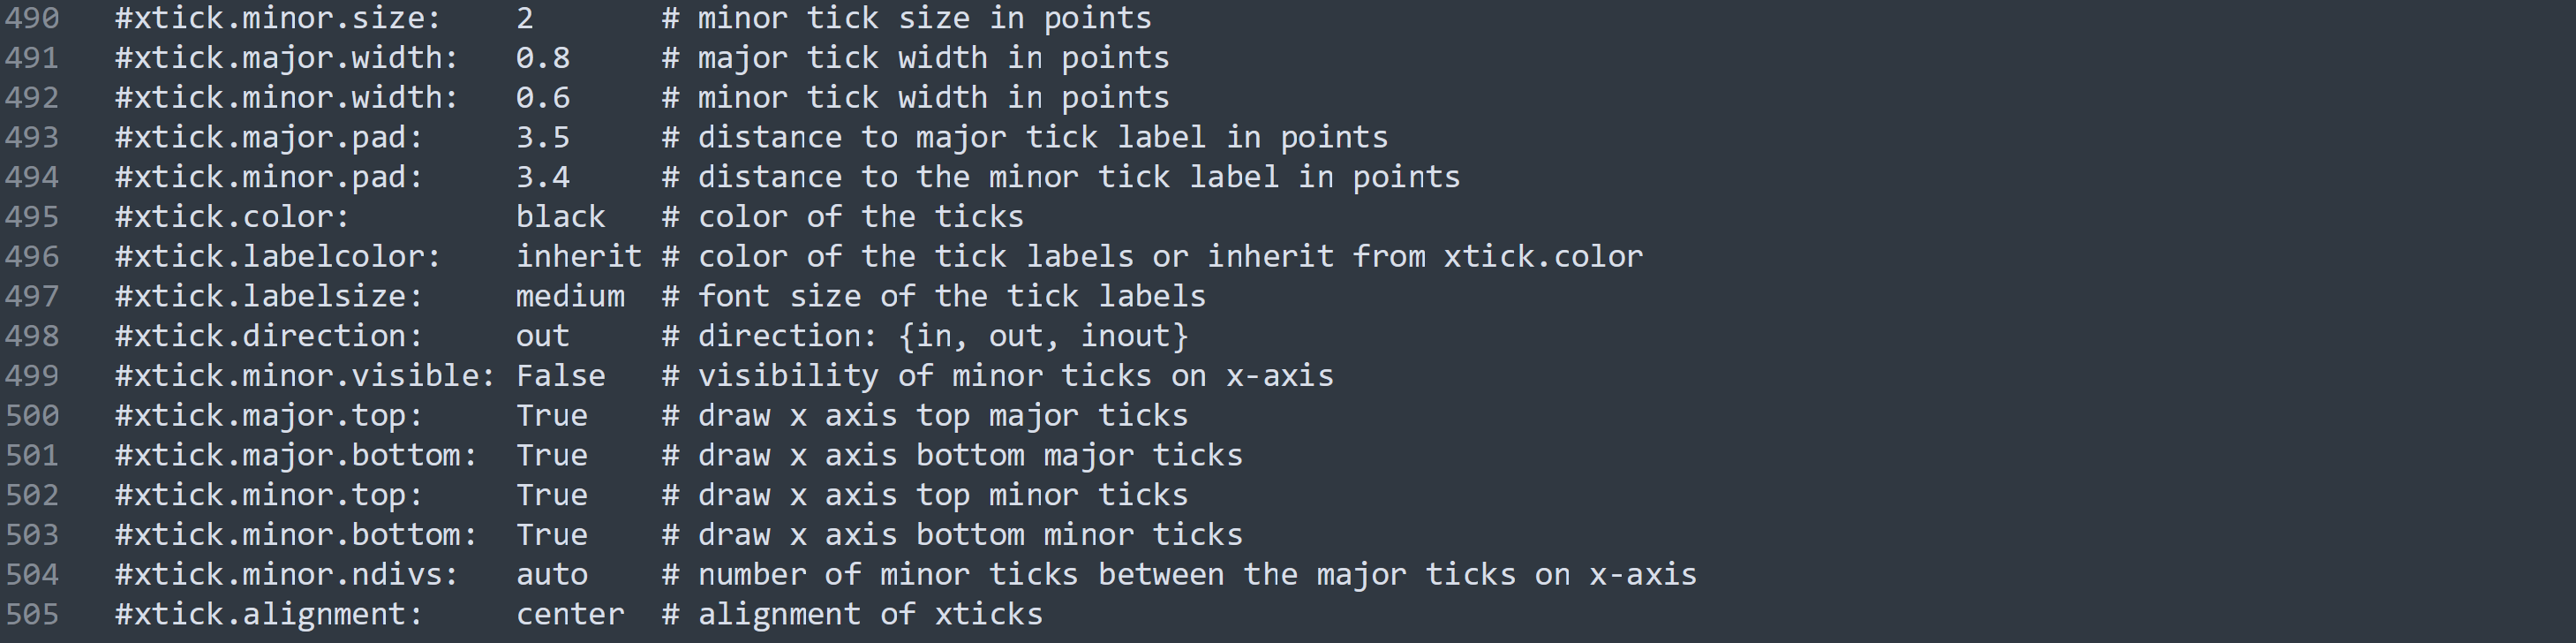

- 下面是在ubuntu Linux系统中的存储位置：
    - /usr/share/matplotlib/mpl-data/matplotlibrc
    - /usr/share/matplotlib/matplotlib.conf/matplotlibrc
    - /etc/matplotlibrc
- 在matplotlib中提供了一个函数get_configdir返回存储的文件名：

In [120]:
import matplotlib.pyplot as plt
import matplotlib as mpl

rc_file = mpl.get_configdir()  # 当前用户的存储文件
print(rc_file)

print(mpl.matplotlib_fname())  # 系统安装时的存储文件。

print(mpl.get_data_path())  # 得到路径

C:\Users\ThinkPad\.matplotlib
C:\Program Files\Python313\Lib\site-packages\matplotlib\mpl-data\matplotlibrc
C:\Program Files\Python313\Lib\site-packages\matplotlib\mpl-data


- 环境变量的默认值恢复：
    - matplotlib提供了一个rcdefaults函数用来得到环境变量的默认值。
    - rc_file_defaults函数从系统存储文件恢复
    - `rc_file(fname, *, use_default_template=True)`从指定文件恢复
- 或者重新构造rcParams对象
    - `matplotlib.rc_params(fail_on_error=False)`从matplotlin的存储文件创建对象
    - `matplotlib.rc_params_from_file(fname, fail_on_error=False, use_default_template=True)`从指定文件重新加载存储文件。

In [129]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["lines.color"] = "red"  # 修改。
mpl.rcdefaults()                     # 直接恢复默认值 。 (没有返回值)
print(mpl.rcParams["lines.color"])   # 恢复后后的默认值。

#########################
rc = mpl.rc_params()    # 返回创建的对象
print(rc["lines.color"])   
print(id(rc), ":", id(mpl.rcParams))   # 

C0
C0
2413284227776 : 2413177364368


- 代码说明：
    - `print(id(rc), ":", id(mpl.rcParams))`，我们比较创建的对象与rcParams实例是否是同一个对象，明显不是。

## 5.2. 环境上下文管理

- 上下文管理提供了一种更加方便的局部环境设置。关于上下文的使用，请复习Python中关于上下文的知识。下面我们直接举例说明。先看上下文的定义：
    - `matplotlib.pyplot.rc_context(rc=None, fname=None)`
        - rc参数：类型为dict的临时环境变量设置。
        - fname参数：使用文件保存的环境变量设置。
        - 如果两个参数同时存在，而且变量名相同，rc的参数优先。不过我们一般很少使用fname来存储需要加载的设置。

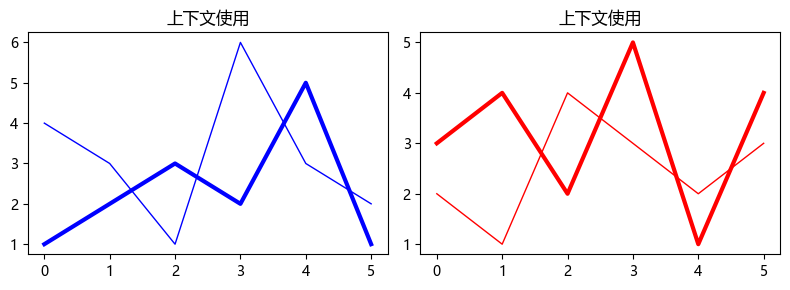

In [148]:
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans', 'STIXGeneral', ]  # 某些字符所在的字库不同，多设置一些字库
plt.rcParams['axes.unicode_minus'] = False    # 宽字符减号支持。

plt.figure(figsize=(8, 3))

with plt.rc_context({"axes.prop_cycle":plt.cycler(color=['blue']), "lines.linewidth":3}):
    plt.subplot(121)
    plt.plot([1, 2, 3, 2, 5, 1])
with plt.rc_context({"axes.prop_cycle":plt.cycler(color=['green']), "lines.linewidth":1}):
    plt.plot([4, 3, 1, 6, 3, 2])
    plt.title('上下文使用')

with plt.rc_context({"axes.prop_cycle":plt.cycler(color=['red']), "lines.linewidth":3}):
    plt.subplot(122)
    plt.plot([3, 4, 2, 5, 1, 4])
    with plt.rc_context({"axes.prop_cycle":plt.cycler(color=['cyan']), "lines.linewidth":1}):
        plt.plot([2, 1, 4, 3, 2, 3])
        plt.title('上下文使用')

    
plt.tight_layout()
plt.show()

- 上下文一般是对Figure环境与Axes环境。
    - 有些环境变量在同一个Axes中切换上下文，无效。这个与Figure与Axes的绘制机制有关。因为lines.color绘制比较特殊。
    - 大部分环境变量在上下文中都工作的很好，上面看见的lines.linewidth就工作的非常好。

-------